In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime
from scipy.signal import windows
from collections import deque
from scipy.optimize import curve_fit
import sqlite3

In [2]:
factor = 1.5
SMALL_SIZE = factor*8
MEDIUM_SIZE = factor*10
BIGGER_SIZE = factor*12
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

Text(0.5, 1.1, 'Before')

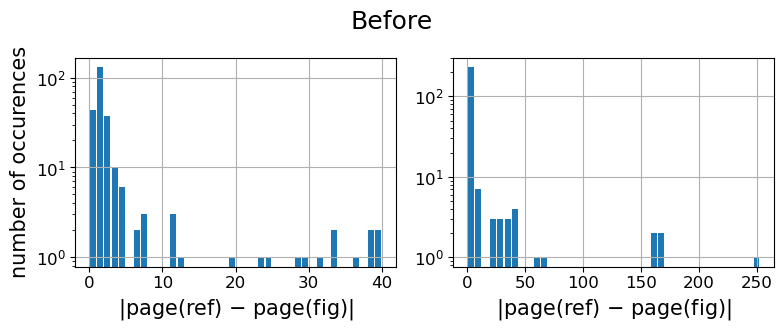

In [99]:
# load data
ref_fig = np.loadtxt("/home/jk/temp/thesis/before.figlog", delimiter=":", usecols=[1,2])
delta = np.abs(ref_fig[:,0] - ref_fig[:,1])

# plot histogram
fig, axx = plt.subplots(ncols=2, figsize=(8,3))
axx[0].hist(delta, rwidth=.8, bins=40, range=[0,40])
axx[1].hist(delta, rwidth=.8, bins=40)

# plot format
axx[0].set_ylabel("number of occurences")
for ax in axx:
    ax.grid()
    ax.set_yscale('log')
    ax.set_xlabel("|page(ref) $-$ page(fig)|")
plt.tight_layout()
plt.suptitle("Before", y=1.1)

The figures referred to from very far away were given a section or page reference:

In [100]:
ref_fig[:,0][delta > 10]

array([ 29., 102., 107., 107., 107., 110., 120., 124., 175., 175., 185.,
       186., 186., 186., 187., 203., 213., 213., 238., 272., 273., 274.,
       274., 299.])

Fig. 71 was reproduced as Fig. 74.

Some figures are referred to from moderately far away:

In [101]:
ref_fig[:,0][(delta < 10) * (delta >2)]

array([ 69., 109., 109., 139., 139., 142., 142., 142., 142., 205., 208.,
       213., 219., 219., 223., 223., 238., 291., 293., 315., 315.])

These were all first mentioned within a page or two of the figure. (Sometimes two consecutive pages of figures or tables mean the figure is two pages away from the first mention.)

Text(0.5, 1.1, 'After')

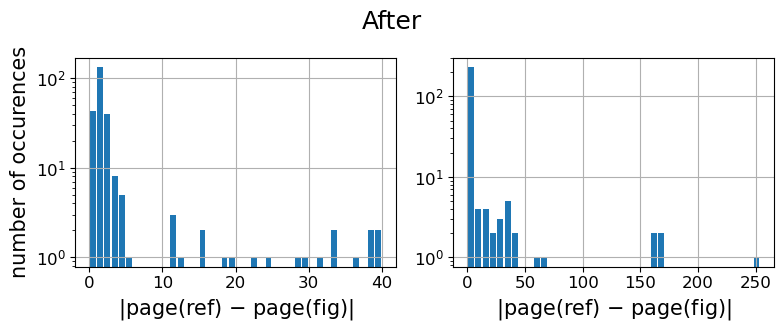

In [112]:
# load data
ref_fig = np.loadtxt("/home/jk/temp/thesis/after.figlog", delimiter=":", usecols=[1,2])
delta = np.abs(ref_fig[:,0] - ref_fig[:,1])

# plot histogram
fig, axx = plt.subplots(ncols=2, figsize=(8,3))
axx[0].hist(delta, rwidth=.8, bins=40, range=[0,40])
axx[1].hist(delta, rwidth=.8, bins=40)

# plot format
axx[0].set_ylabel("number of occurences")
for ax in axx:
    ax.grid()
    ax.set_yscale('log')
    ax.set_xlabel("|page(ref) $-$ page(fig)|")
plt.tight_layout()
plt.suptitle("After", y=1.1)

In [104]:
ref_fig[:,0][(delta < 10) * (delta >2)]

array([109., 109., 139., 139., 142., 142., 142., 142., 209., 239., 292.,
       294., 316., 316.])